In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as pp
import sklearn.metrics as ms
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [265]:
df=pd.read_csv(r"C:\Users\Lenovo\Downloads\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [266]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

We are deleting this columns,because we don't need these data's while we re creating our Model

In [267]:
df=df.merge(pd.get_dummies(df['Sex'],dtype=int,drop_first=True),left_index=True,right_index=True)
df.drop(columns='Sex',inplace=True)
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male
0,0,3,22.0,1,0,7.2500,S,1
1,1,1,38.0,1,0,71.2833,C,0
2,1,3,26.0,0,0,7.9250,S,0
3,1,1,35.0,1,0,53.1000,S,0
4,0,3,35.0,0,0,8.0500,S,1
...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,1
887,1,1,19.0,0,0,30.0000,S,0
888,0,3,NaN,1,2,23.4500,S,0
889,1,1,26.0,0,0,30.0000,C,1


We are making One-Hot encoding to replace male/female with numeric 0/1

In [268]:
df['FamilySize']=df['SibSp']+df['Parch']+1
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male,FamilySize
0,0,3,22.0,1,0,7.2500,S,1,2
1,1,1,38.0,1,0,71.2833,C,0,2
2,1,3,26.0,0,0,7.9250,S,0,1
3,1,1,35.0,1,0,53.1000,S,0,2
4,0,3,35.0,0,0,8.0500,S,1,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,1,1
887,1,1,19.0,0,0,30.0000,S,0,1
888,0,3,NaN,1,2,23.4500,S,0,4
889,1,1,26.0,0,0,30.0000,C,1,1


Here we have created new column with the sum of SibSb and Parch +1(himself/herself) to find the number of that person's family,and to analyse the relation with Survived column

**EDA**

<Axes: xlabel='Embarked', ylabel='Survived'>

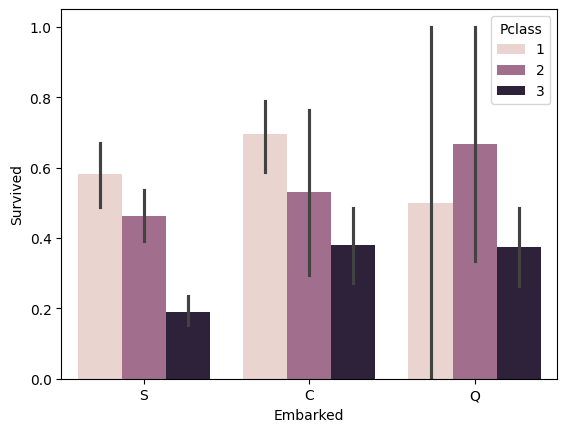

In [269]:
sns.barplot(x='Embarked',y='Survived',hue='Pclass',data=df)

In [270]:
embarked_df = pd.DataFrame({
    "Code": ["C", "Q", "S"],
    "Port": ["Cherbourg", "Queenstown", "Southampton"],
    "Country": ["France", "Ireland", "England"]
})

print(embarked_df)

  Code         Port  Country
0    C    Cherbourg   France
1    Q   Queenstown  Ireland
2    S  Southampton  England


We plotted a barplot to analyze the relationship between Embarked and Survived, taking Pclass (1, 2, 3) into account.

Observations:

For S and C ports, the survival rate decreases with lower class levels:

Pclass 1 > Pclass 2 > Pclass 3
Pclass 1 > Pclass 2 > Pclass 3

This indicates that passengers boarding at S (Southampton) and C (Cherbourg) tended to be from wealthier ports, as higher class passengers are more concentrated there.


Embarked port is correlated with survival, partly due to its correlation with Pclass (ticket class).

<Axes: xlabel='male', ylabel='Survived'>

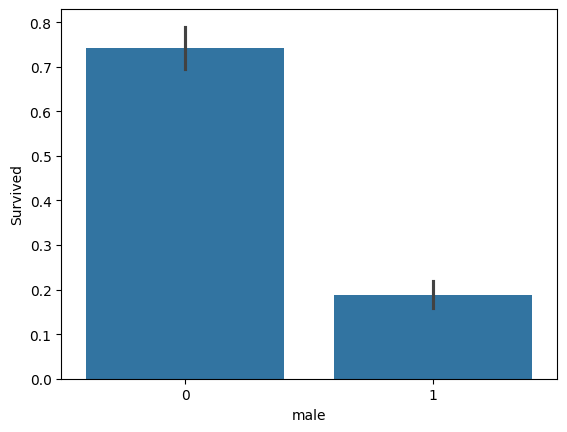

In [271]:
sns.barplot(x='male',y='Survived',data=df)

We analyzed the relationship between Sex (male/female) and Survival rates.

From the visualization, we can observe that most of the passengers who died were men, while women had a significantly higher survival rate on the Titanic.

Insight:
This pattern reflects the historical evacuation rule “women and children first”, which increased the survival probability of female passengers.

<Axes: xlabel='FamilySize', ylabel='Survived'>

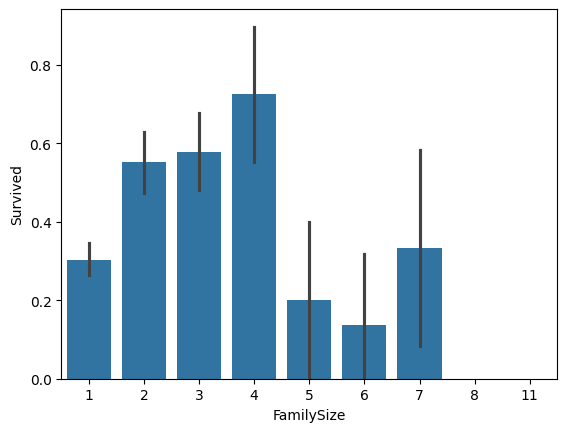

In [287]:
sns.barplot(x='FamilySize',y='Survived',data=df)

The visualization indicates that there is no strong relationship between FamilySize and the survival outcome. To confirm this observation, we will analyze the correlation matrix. If the feature does not contribute significantly to the model, it may be removed along with other related variables.

In [272]:
df=pd.get_dummies(df,columns=['Embarked'],dtype=int,drop_first=True)

One-Hot Encoding is applied to transform categorical features into numerical variables. This process creates separate binary columns (0 or 1) for each category, allowing machine learning algorithms to properly process categorical data.

In [273]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [274]:
df['Age']=df['Age'].fillna(df['Age'].median())
# We had some NaN values on Age column, using median of Age column ,we have filled it

**Slicing and Scaling**

In [275]:
X_train, X_test, y_train, y_test =train_test_split(df.drop(columns=['Survived']),df[['Survived']],test_size=0.25,random_state=25)

In [276]:
ss=pp.RobustScaler()
X_train[['Age','Fare']]=ss.fit_transform(X_train[['Age','Fare']])
X_test[['Age','Fare']]=ss.transform(X_test[['Age','Fare']])

In [277]:
X_train

,Pclass,Age,SibSp,Parch,Fare,male,FamilySize,Embarked_Q,Embarked_S
161,2,1.000000,0,0,0.061025,0,1,0,1
776,3,0.000000,0,0,-0.300607,1,1,1,0
280,3,3.083333,0,0,-0.300607,1,1,1,0
276,3,1.416667,0,0,-0.300607,0,1,0,1
598,3,0.000000,0,0,-0.324339,1,1,0,0
...,...,...,...,...,...,...,...,...,...
317,2,2.166667,0,0,-0.018082,1,1,0,1
143,3,-0.750000,0,0,-0.345811,1,1,1,0
474,3,-0.500000,0,0,-0.206244,0,1,0,1
318,1,0.250000,0,2,6.801708,0,3,0,1


In [278]:
X_train.merge(y_train,left_index=True,right_index=True).corr()

,Pclass,Age,SibSp,Parch,Fare,male,FamilySize,Embarked_Q,Embarked_S,Survived
Pclass,1.000000,-0.311306,0.088750,0.032705,-0.543843,0.149830,0.077071,0.207049,0.094168,-0.312580
Age,-0.311306,1.000000,-0.243394,-0.203091,0.077255,0.067496,-0.266843,-0.018608,-0.044961,-0.099243
SibSp,0.088750,-0.243394,1.000000,0.426463,0.182703,-0.086079,0.896758,-0.037812,0.081826,-0.058532
Parch,0.032705,-0.203091,0.426463,1.000000,0.208421,-0.238655,0.782697,-0.070971,0.062088,0.069089
Fare,-0.543843,0.077255,0.182703,0.208421,1.000000,-0.217998,0.227689,-0.111003,-0.150441,0.253225
male,0.149830,0.067496,-0.086079,-0.238655,-0.217998,1.000000,-0.175992,-0.109928,0.138774,-0.547291
FamilySize,0.077071,-0.266843,0.896758,0.782697,0.227689,-0.175992,1.000000,-0.060741,0.086682,-0.006475
Embarked_Q,0.207049,-0.018608,-0.037812,-0.070971,-0.111003,-0.109928,-0.060741,1.000000,-0.506714,0.022029
Embarked_S,0.094168,-0.044961,0.081826,0.062088,-0.150441,0.138774,0.086682,-0.506714,1.000000,-0.149889
Survived,-0.312580,-0.099243,-0.058532,0.069089,0.253225,-0.547291,-0.006475,0.022029,-0.149889,1.000000


A correlation matrix is used to analyze the relationships between features and the target variable. This helps identify the most influential variables for prediction. Features that are highly correlated with each other may be removed to reduce multicollinearity and improve the model's generalization, which also helps prevent overfitting.

In [279]:
unrelated_colms=['SibSp','Parch','FamilySize','Embarked_Q','Age']
X_train.drop(columns=unrelated_colms,inplace=True)
X_test.drop(columns=unrelated_colms,inplace=True)




In [280]:
X_train

,Pclass,Fare,male,Embarked_S
161,2,0.061025,0,1
776,3,-0.300607,1,0
280,3,-0.300607,1,0
276,3,-0.300607,0,1
598,3,-0.324339,1,0
...,...,...,...,...
317,2,-0.018082,1,1
143,3,-0.345811,1,0
474,3,-0.206244,0,1
318,1,6.801708,0,1


**Logistic Regression Modelling**

In [281]:
lr=LogisticRegression(C=4000)
lr.fit(X_train,y_train)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",4000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

In [282]:
ms.accuracy_score(y_train,lr.predict(X_train))

0.7874251497005988

In [283]:
accuracy_score=ms.accuracy_score(y_test,lr.predict(X_test))
print("Accuracy:",accuracy_score)

Accuracy: 0.7802690582959642


In [284]:
cm=ms.confusion_matrix(y_test,lr.predict(X_test))
print(cm)

[[118  23]
 [ 26  56]]


In [285]:
a=ms.classification_report(y_test,lr.predict(X_test))
print(a)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       141
           1       0.71      0.68      0.70        82

    accuracy                           0.78       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.78      0.78      0.78       223



    precision    recall  f1-score   support

           0       0.82      0.84      0.83       141
           1       0.71      0.68      0.70        82

    accuracy                           0.78       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.78      0.78      0.78       223

Model predicts deaths more accurately than survivals
Dataset is slightly imbalanced (more deaths than survivors)

Logistic Regression achieves 78% accuracy on the test set
Model is interpretable: coefficients show how each feature affects survival